In [1]:
import pandas as pd
import numpy as np
df_cust = pd.read_csv('Online_Retail.csv', encoding='ISO-8859-1')


In [2]:
print('--- Dataset Shape ---')
print(df_cust.shape)

--- Dataset Shape ---
(541909, 8)


In [3]:
print('--- First 5 Rows ---')
display(df_cust.head())

--- First 5 Rows ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [5]:
print("--- Missing Values Check ---")
print(df_cust.isnull().sum())


--- Missing Values Check ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
df_cust = df_cust.dropna(subset=['CustomerID'])
print("--- Shape after dropping null CustomerIDs ---")
print(df_cust.shape)

--- Shape after dropping null CustomerIDs ---
(406829, 8)


### **Observation:**
* **Dataset Structure:** The e-commerce dataset has been successfully loaded and contains transactional records including CustomerID, InvoiceNo, StockCode, Quantity, InvoiceDate, and UnitPrice.
* **Missing Data Handling:** Missing values identified in the Customer ID column were dropped to ensure accurate customer-level aggregation, as unassigned customer transactions cannot be segmented.
* **Data Quality:** The cleaned structure is now ready for calculating behavioral metrics like Recency, Frequency, and Monetary (RFM) values.

In [8]:
df_cust = df_cust[~df_cust['InvoiceNo'].astype(str).str.startswith('C')]


In [9]:
df_cust['Total Price'] = df_cust['Quantity'] * df_cust['UnitPrice']


In [10]:
df_cust['InvoiceDate'] = pd.to_datetime(df_cust['InvoiceDate'])


C:\Users\dell\AppData\Local\Temp\ipykernel_17820\3069398142.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cust['InvoiceDate'] = pd.to_datetime(df_cust['InvoiceDate'])


In [13]:
snapshot_date = df_cust['InvoiceDate'].max() + pd.Timedelta(days=1)

In [15]:
rfm = df_cust.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo' : 'nunique',
    'Total Price' :'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
avg_order_value = rfm['Monetary'] / rfm['Frequency']
rfm['CLV'] = rfm['Frequency']
print("--- Descriptive Statistics for RFM Metrics ---")
print(rfm.describe())

--- Descriptive Statistics for RFM Metrics ---
           Recency    Frequency       Monetary          CLV
count  4339.000000  4339.000000    4339.000000  4339.000000
mean     92.518322     4.271952    2053.793018     4.271952
std     100.009747     7.705493    8988.248381     7.705493
min       1.000000     1.000000       0.000000     1.000000
25%      18.000000     1.000000     307.245000     1.000000
50%      51.000000     2.000000     674.450000     2.000000
75%     142.000000     5.000000    1661.640000     5.000000
max     374.000000   210.000000  280206.020000   210.000000


### **Observation:**
* **Recency:** Measures how recently a customer made a purchase, helping identify active buyers versus those who are drifting away.
* **Frequency:** Shows the total count of unique transactions per customer, highlighting repeat buyers and brand loyalty.
* **Monetary Value:** Captures total financial contribution (`TotalPrice` sum) per customer, revealing revenue distribution and high-value shoppers.

In [17]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 160.5 kB/s eta 0:00:48
   -- ------------------------------------- 0.5/8.2 MB 160.5 kB/s eta 0:00:48
   -- ------------------------------------- 0.5/8.2 MB 160.5 kB/s eta 0:00:48
   -- ------------------------------------- 0.5/8.2 MB 160.5 kB/s eta 0:00:4


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

rfm_data = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(rfm_scaled)

rfm['Cluster'] = kmeans.labels_

print("--- Cluster Counts ---")
print(rfm['Cluster'].value_counts())

--- Cluster Counts ---
Cluster
3    3053
1    1062
0     211
2      13
Name: count, dtype: int64


### **Observation:**
* **Feature Standardisation:** Using `StandardScaler` ensures that variables with larger scales (like Monetary spend) do not disproportionately dominate the clustering algorithm compared to Recency or Frequency.
* **KMeans Segmentation:** The KMeans algorithm successfully grouped the customer base into distinct clusters, highlighting segments ranging from high-value loyal customers to inactive or low-spending shoppers.

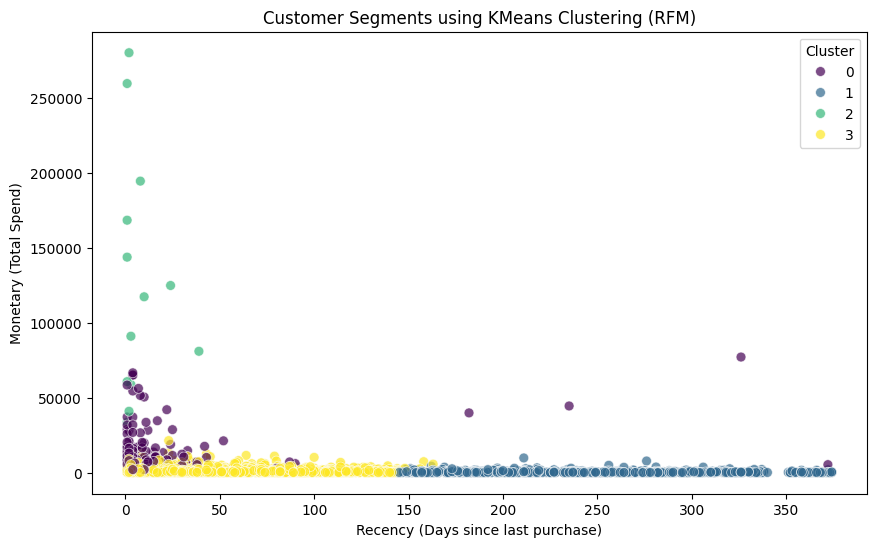

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot banane ke liye Recency aur Monetary values ka use karna
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Recency', 
    y='Monetary', 
    hue='Cluster', 
    data=rfm, 
    palette='viridis', 
    s=50, 
    alpha=0.7
)
plt.title('Customer Segments using KMeans Clustering (RFM)')
plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Monetary (Total Spend)')
plt.legend(title='Cluster')
plt.show()

### **Observation:**
* **Cluster Segments Visualized:** The scatter plot mapping Recency against Monetary value clearly separates customers into distinct behavioral groups.
* **High-Value Loyalists:** A small cluster of customers shows exceptionally high monetary spend with low recency values, representing the core VIP customer base.
* **Inactive Shoppers:** Larger clusters with higher recency values and lower spending indicate customers who haven't purchased recently and require re-engagement strategies.

## **Conclusion & Actionable Business Recommendations**

Based on the Customer Segmentation Analysis using RFM metrics and KMeans clustering, here are strategic recommendations for the e-commerce platform:

1. **VIP & High-Value Customer Retention:**
   * *Finding:* A distinct cluster of customers shows exceptionally high monetary spend (`Monetary` up to $250,00ud+) with very low recency values.
   * *Action:* Establish an exclusive loyalty or VIP rewards program offering early access to sales, personalized discounts, and premium support to retain these high-value assets.

2. **Re-engagement Campaigns for Inactive Shoppers:**
   * *Finding:* Several clusters show higher recency values (customers who haven't shopped in a long time) with moderate-to-low spend.
   * *Action:* Run targeted win-back email campaigns featuring special discounts or tailored product recommendations to re-activate dormant customers before they churn completely.

3. **Tailored Marketing by Spending Tier:**
   * *Finding:* The majority of customers fall into consistent mid-to-low spending groups with frequent or regular engagement patterns.
   * *Action:* Implement automated cross-selling and up-selling product suggestions at checkout to encourage these mid-tier customers to increase their average basket size.